In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Generate a synthetic dataset mimicking your Task 1 feature structure
np.random.seed(42)
num_matches = 500

data = {
    'home_team_form': np.random.randint(1, 6, num_matches),
    'away_team_form': np.random.randint(1, 6, num_matches),
    'home_won_toss': np.random.randint(0, 2, num_matches),
    'day_match': np.random.randint(0, 2, num_matches),
    'home_rest_days': np.random.randint(1, 5, num_matches),
    'away_rest_days': np.random.randint(1, 5, num_matches)
}

df = pd.DataFrame(data)

# Simulate a target win condition: home team wins more if form is high or they win the toss
win_probability = (df['home_team_form'] * 0.15) - (df['away_team_form'] * 0.12) + (df['home_won_toss'] * 0.1) + np.random.normal(0, 0.1, num_matches)
df['winner'] = (win_probability > np.median(win_probability)).astype(int)

# 2. Separate features and target label
X = df.drop(columns=['winner']) 
y = df['winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the model directly right here
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

print("Fresh dataset created and model trained successfully inside the notebook!")

Fresh dataset created and model trained successfully inside the notebook!


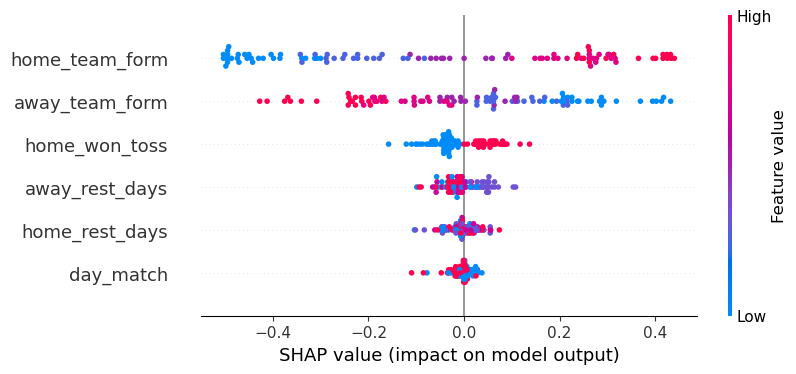

In [4]:
# 1. Initialize the SHAP Explainer using the model we just trained
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# 2. Draw the Global Feature Importance Beeswarm Plot for Class 1 (Winning)
plt.figure(figsize=(8, 4))
shap.plots.beeswarm(shap_values[:, :, 1])

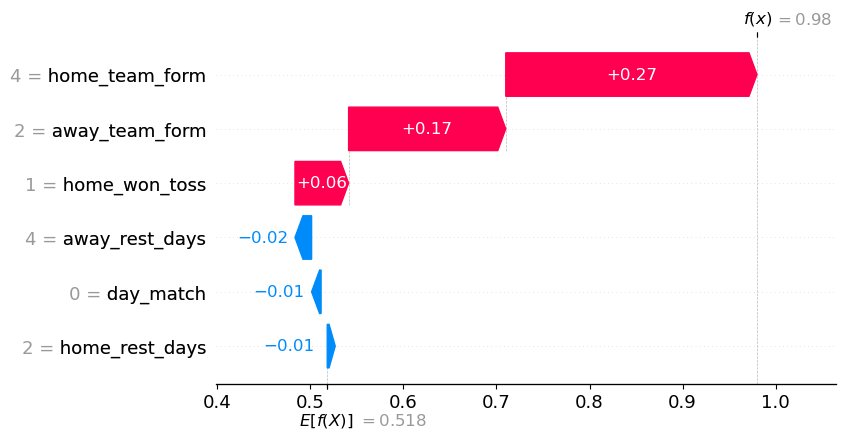

In [5]:
# Draw the Local Waterfall Plot for the first match, focusing on Class 1 (Winning)
plt.figure(figsize=(8, 4))
shap.plots.waterfall(shap_values[0, :, 1])

In [6]:
# Create a dataframe to compare predictions vs actual outcomes
analysis_df = X_test.copy()
analysis_df['actual'] = y_test.values
analysis_df['predicted'] = model.predict(X_test)
analysis_df['is_correct'] = analysis_df['actual'] == analysis_df['predicted']

print("--- Accuracy Breakdown: Did winning the toss alter model correctness? ---")
print(analysis_df.groupby('home_won_toss')['is_correct'].mean())

--- Accuracy Breakdown: Did winning the toss alter model correctness? ---
home_won_toss
0    0.868852
1    0.871795
Name: is_correct, dtype: float64
